# LDS sweeps from `runs.db`

Pulls LDS rows out of the SQLite store at `experiments/outputs/runs.db` and slices them four ways for one fixed `(run_id, model_id)`:

| Variant | Fixed | Lines       | x-axis  |
|---------|-------|-------------|---------|
| 1       | method  | damping       | epoch   |
| 2       | damping | method        | epoch   |
| 3       | epoch   | method        | damping |
| 4       | method  | _(heatmap)_   | damping × epoch |

Each variant has a per-fixed-value loop and a single combined facet figure.

Error bands on line plots use `ci_low/ci_high` from the LDS bootstrap; the heatmap omits uncertainty on purpose.

## Setup

In [3]:
from __future__ import annotations

import sqlite3
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm, colormaps
from matplotlib.colors import LogNorm, Normalize

DB_PATH = Path("/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/runs.db")

COLORS = {
    "kfac": "#1f77b4",
    "ekfac": "#ff7f0e",
    "gnh": "#d62728",
    "fim": "#2ca02c",
    "block_fim": "#9467bd",
    "block_hessian": "#8c564b",
    "shampoo": "#e377c2",
    "eshampoo": "#7f7f7f",
    "identity": "#17becf",
    "exact": "#bcbd22",
    "mac": "#393b79",
    "emac": "#637939",
}
LABELS = {
    "kfac": "K-FAC",
    "ekfac": "EK-FAC",
    "gnh": "GNH",
    "fim": "FIM",
    "block_fim": "Block FIM",
    "block_hessian": "Block Hessian",
    "shampoo": "Shampoo",
    "eshampoo": "E-Shampoo",
    "identity": "Identity",
    "exact": "Exact",
    "mac": "MAC",
    "emac": "E-MAC",
}
APPROX_ORDER = [
    "exact",
    "gnh",
    "fim",
    "mac",
    "emac",
    "block_hessian",
    "block_fim",
    "shampoo",
    "eshampoo",
    "ekfac",
    "kfac",
    "identity",
]

plt.rcParams.update({"font.size": 11})


def open_db(path: Path = DB_PATH) -> sqlite3.Connection:
    if not path.exists():
        raise FileNotFoundError(f"runs.db not found at {path}")
    return sqlite3.connect(str(path))


def load_runs_db(db_path: Path = DB_PATH) -> pd.DataFrame:
    """results ⋕ (metrics ⋗ influence on result_id+approximator) ⋕ runs.

    `influence.method` is renamed to `approximator` to align with metrics.
    """
    DROP_FROM_RUNS = {"params_json", "code_sha"}
    DROP_FROM_RESULTS = {"params_json"}
    with open_db(db_path) as con:
        runs = pd.read_sql_query("SELECT * FROM runs", con).drop(
            columns=list(DROP_FROM_RUNS), errors="ignore"
        )
        results = pd.read_sql_query("SELECT * FROM results", con).drop(
            columns=list(DROP_FROM_RESULTS), errors="ignore"
        )
        metrics = pd.read_sql_query("SELECT * FROM metrics", con)
        influence = pd.read_sql_query(
            "SELECT *, method AS approximator FROM influence", con
        ).drop(columns=["method"])
    method_keyed = metrics.merge(
        influence, on=["result_id", "approximator"], how="outer"
    )
    return results.merge(method_keyed, on="result_id", how="left").merge(
        runs, on="run_id", how="left"
    )


def _order_methods(methods: list[str]) -> list[str]:
    rank = {m: i for i, m in enumerate(APPROX_ORDER)}
    return sorted(methods, key=lambda m: (rank.get(m, len(rank)), m))

## Load + slice

Pull the whole DB once, drop rows with no LDS, then fix one `(run_id, model_id)`. Strategy is kept as a column so multi-strategy runs still split cleanly.

In [16]:
df = load_runs_db()
df_lds = df[df["lds_mean"].notna()].copy()
df_lds = df_lds.drop_duplicates(
    subset=[
        "run_id",
        "model_id",
        "epoch",
        "approximator",
        "damping_value",
        "damping_strategy",
    ]
)
print(f"{len(df_lds)} LDS rows across {df_lds['run_id'].nunique()} runs")
print("available run_ids:", sorted(df_lds["run_id"].unique()))

1595 LDS rows across 9 runs
available run_ids: ['20260430-202949', '20260501-072804', '20260501-073025', '20260501-073105', '20260501-073145', '20260501-144047', '20260501-150319', '20260503-120759', '20260503-131554']


In [17]:
RUN_ID = "20260503-120759"

# pick the first model in this run (the question said: fix run → fixes model).
model_ids = sorted(df_lds[df_lds["run_id"] == RUN_ID]["model_id"].unique())
if not model_ids:
    raise ValueError(f"no LDS rows for run_id={RUN_ID}")
MODEL_ID = model_ids[0]
print(f"RUN_ID  = {RUN_ID}")
print(f"MODEL_ID = {MODEL_ID}   ({len(model_ids)} model(s) in this run)")

df_sub = df_lds[(df_lds["run_id"] == RUN_ID) & (df_lds["model_id"] == MODEL_ID)].copy()
df_sub = df_sub[
    [
        "approximator",
        "epoch",
        "damping_value",
        "damping_strategy",
        "lds_mean",
        "lds_std",
        "lds_ci_low",
        "lds_ci_high",
        "lds_num_valid_queries",
    ]
].sort_values(["approximator", "epoch", "damping_value"])

EPOCHS = sorted(df_sub["epoch"].dropna().unique().astype(int).tolist())
DAMPINGS = sorted(df_sub["damping_value"].dropna().unique().tolist())
STRATEGIES = sorted(df_sub["damping_strategy"].dropna().unique().tolist())
METHODS = _order_methods(df_sub["approximator"].dropna().unique().tolist())

print(f"epochs:     {EPOCHS}")
print(f"dampings:   {DAMPINGS}")
print(f"strategies: {STRATEGIES}")
print(f"methods:    {METHODS}")
df_sub.head()

RUN_ID  = 20260503-120759
MODEL_ID = resnet_mlp_fbc1db7ec868   (1 model(s) in this run)
epochs:     [4, 8, 12, 16, 20]
dampings:   [1e-09, 1e-06, 0.001, 0.01, 0.1, 1.0]
strategies: ['uniform']
methods:    ['mac', 'emac', 'shampoo', 'eshampoo', 'ekfac', 'kfac', 'identity', 'eidentity']


,approximator,epoch,damping_value,damping_strategy,lds_mean,lds_std,lds_ci_low,lds_ci_high,lds_num_valid_queries
35272,eidentity,4,1.000000e-09,uniform,0.172873,0.110521,0.141658,0.199817,179.0
35264,eidentity,4,1.000000e-06,uniform,0.172273,0.110490,0.141113,0.199098,179.0
35256,eidentity,4,1.000000e-03,uniform,0.145934,0.108756,0.113627,0.174269,179.0
35248,eidentity,4,1.000000e-02,uniform,0.134315,0.108710,0.100156,0.162984,179.0
35240,eidentity,4,1.000000e-01,uniform,0.130580,0.108637,0.096222,0.160083,179.0


## Plotting helpers

All three line-plot variants share the same one-panel routine `_lds_lines_panel`. It draws one line per group with a CI band, applies a colour map decided by the caller, and labels via `LABELS`. The grid wrappers re-use it for the “one big plot” versions.

- **Damping colourmap**: `viridis` on `log10(damping)` (covers nine orders of magnitude).
- **Method colourmap**: the project-wide `COLORS` dict.
- **Epoch colourmap**: `plasma` on linear epoch index.
- **Linestyle** distinguishes `damping_strategy` when more than one is present.

In [18]:
_LINESTYLES = ["-", "--", ":", "-."]


def _strategy_styles(strategies: list[str]) -> dict[str, str]:
    return {
        s: _LINESTYLES[i % len(_LINESTYLES)] for i, s in enumerate(sorted(strategies))
    }


def _damping_color(
    d: float, *, vmin: float, vmax: float, cmap_name: str = "viridis"
) -> tuple:
    norm = LogNorm(vmin=vmin, vmax=vmax)
    return colormaps[cmap_name](norm(d))


def _epoch_color(e: int, *, vmin: int, vmax: int, cmap_name: str = "plasma") -> tuple:
    norm = Normalize(vmin=vmin, vmax=max(vmax, vmin + 1))
    return colormaps[cmap_name](norm(e))


def _method_color(m: str) -> tuple:
    return COLORS.get(m, "#444444")


def _lds_lines_panel(
    ax,
    sub: pd.DataFrame,
    *,
    x_col: str,
    group_col: str,
    color_for: callable,
    label_for: callable,
    log_x: bool = False,
    show_band: bool = True,
    style_col: Optional[str] = "damping_strategy",
    style_map: Optional[dict[str, str]] = None,
):
    """One panel: one line per group, x = `x_col`, y = lds_mean (with CI band).

    Linestyle splits by `style_col` when `style_map` has ≥2 entries.
    Returns the list of legend handle/label tuples for this panel.
    """
    if sub.empty:
        ax.text(
            0.5,
            0.5,
            "no data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
        ax.set_axis_off()
        return []

    use_style = (
        style_map is not None and len(style_map) > 1 and style_col in sub.columns
    )
    legend_entries: list[tuple] = []

    for g, gdf in sub.groupby(group_col, sort=False):
        gdf = gdf.sort_values(x_col)
        color = color_for(g)
        if use_style:
            inner_iter = gdf.groupby(style_col, sort=False)
        else:
            inner_iter = [(None, gdf)]
        for s, sdf in inner_iter:
            sdf = sdf.sort_values(x_col)
            ls = style_map.get(s, "-") if use_style else "-"
            x = sdf[x_col].to_numpy()
            y = sdf["lds_mean"].to_numpy()
            label = label_for(g)
            if use_style:
                label = f"{label_for(g)} · {s}"
            (line,) = ax.plot(
                x, y, color=color, lw=1.6, marker="o", ms=3.5, ls=ls, label=label
            )
            if show_band and "lds_ci_low" in sdf and "lds_ci_high" in sdf:
                lo = sdf["lds_ci_low"].to_numpy()
                hi = sdf["lds_ci_high"].to_numpy()
                if np.isfinite(lo).any() and np.isfinite(hi).any():
                    ax.fill_between(x, lo, hi, color=color, alpha=0.12, linewidth=0)
            legend_entries.append((line, label))

    ax.axhline(0.0, color="black", lw=0.6, alpha=0.4)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if log_x:
        ax.set_xscale("log")
    return legend_entries

## Variant 1 — fix **method**, vary epoch × damping

x = epoch, one line per damping value (colour = `viridis(log damping)`).

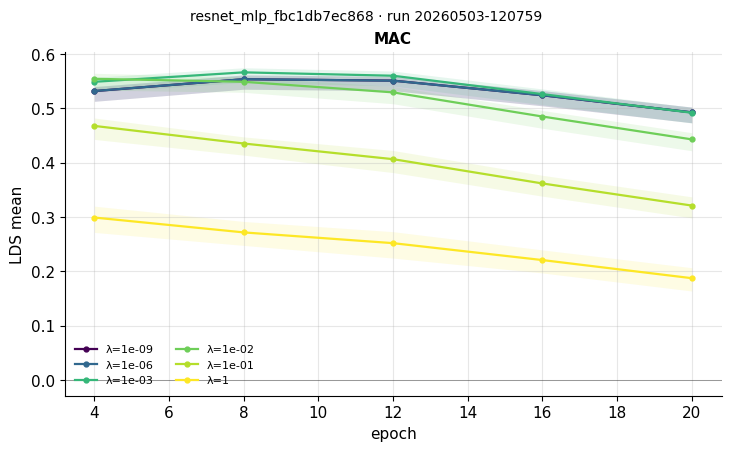

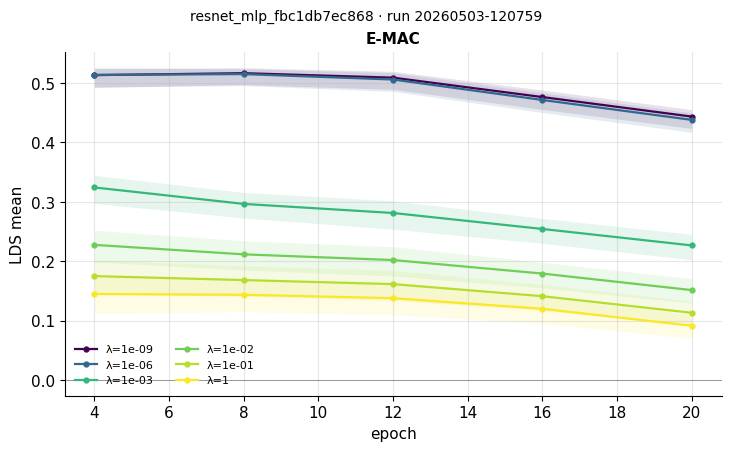

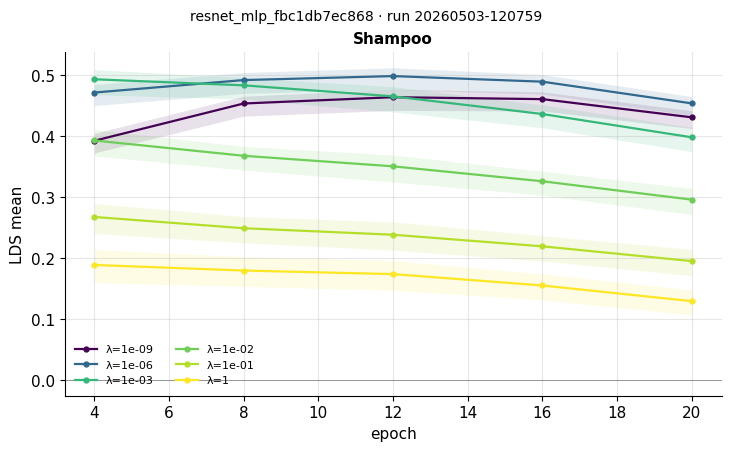

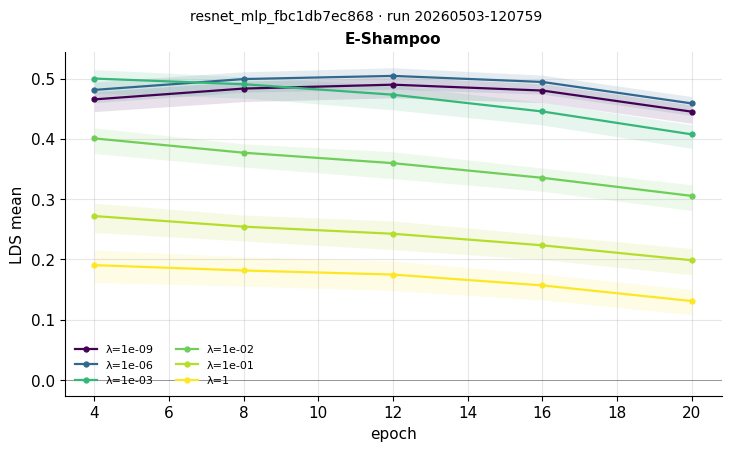

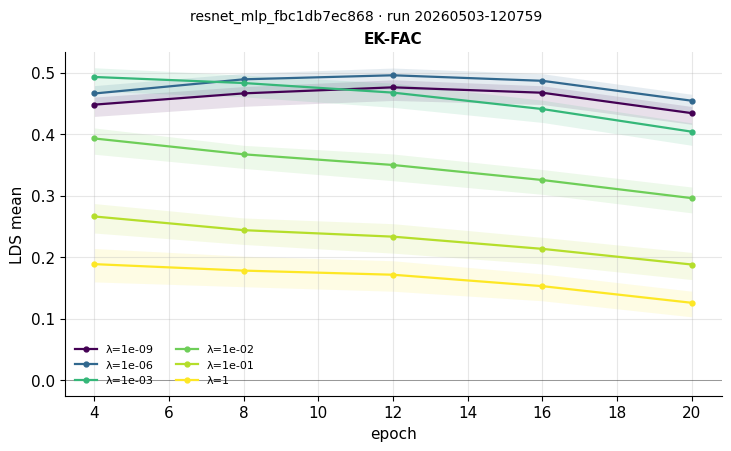

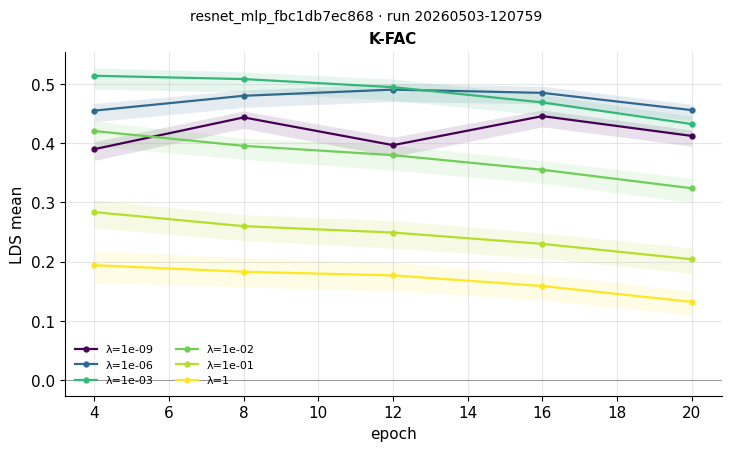

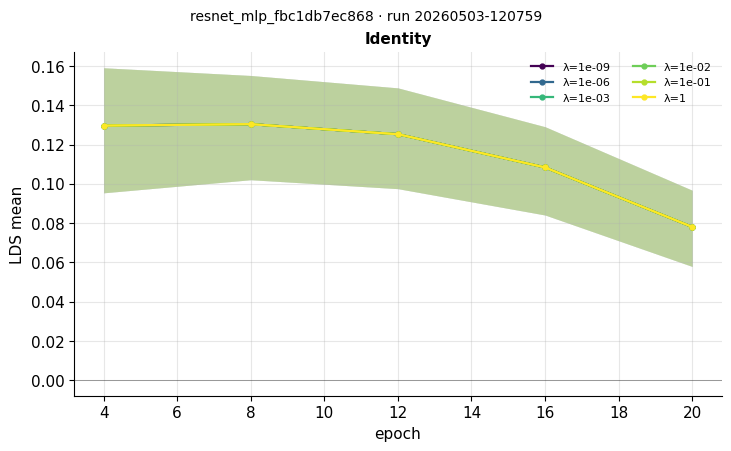

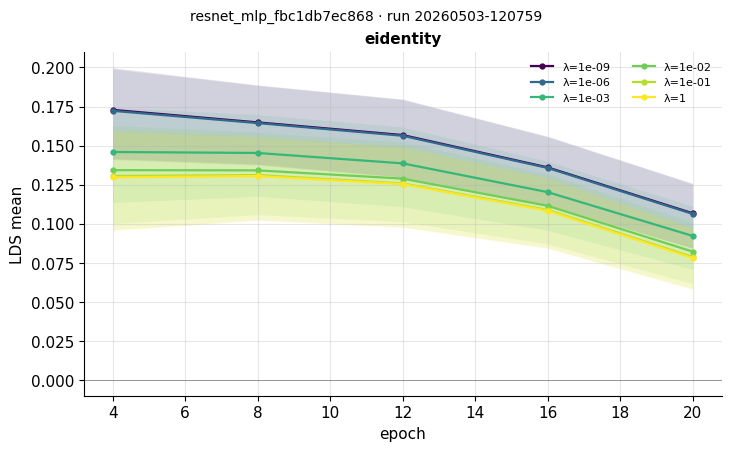

In [19]:
def plot_lds_methodfix(
    df_sub: pd.DataFrame,
    method: str,
    *,
    ax=None,
    show_legend: bool = True,
    show_band: bool = True,
):
    sub = df_sub[df_sub["approximator"] == method]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
    else:
        fig = ax.get_figure()

    dmin = max(min(DAMPINGS), 1e-12) if DAMPINGS else 1e-12
    dmax = max(DAMPINGS) if DAMPINGS else 1.0
    style_map = _strategy_styles(sub["damping_strategy"].dropna().unique().tolist())

    _lds_lines_panel(
        ax,
        sub,
        x_col="epoch",
        group_col="damping_value",
        color_for=lambda d: _damping_color(d, vmin=dmin, vmax=dmax),
        label_for=lambda d: f"λ={d:.0e}" if d not in (0, 1) else f"λ={d:g}",
        log_x=False,
        show_band=show_band,
        style_map=style_map if len(style_map) > 1 else None,
    )
    ax.set_xlabel("epoch")
    ax.set_ylabel("LDS mean")
    ax.set_title(f"{LABELS.get(method, method)}", fontsize=11, fontweight="bold")
    if show_legend:
        ax.legend(
            loc="best", fontsize=8, ncol=2 if len(DAMPINGS) > 4 else 1, frameon=False
        )
    return fig


for m in METHODS:
    fig = plot_lds_methodfix(df_sub, m)
    fig.suptitle(f"{MODEL_ID} · run {RUN_ID}", fontsize=10)
    plt.show()

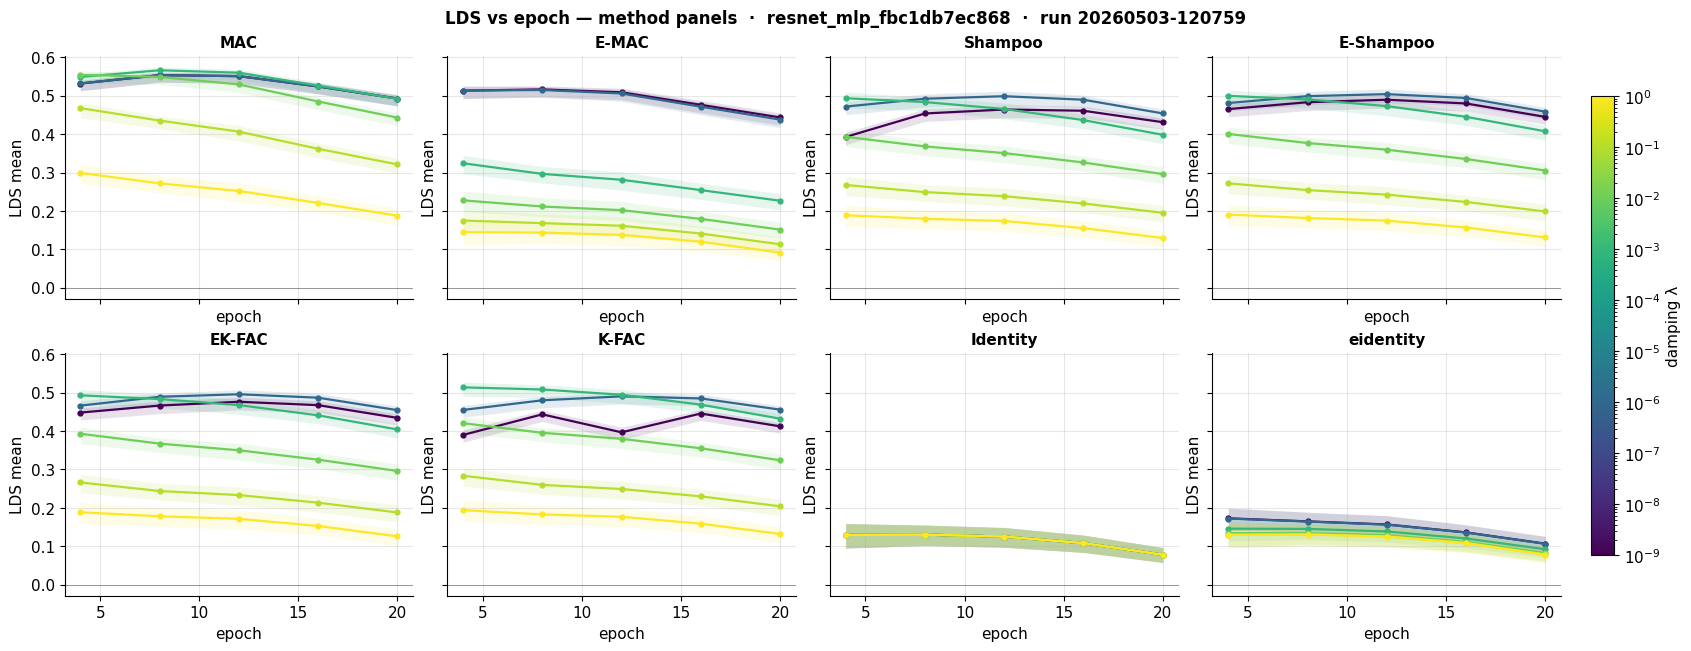

In [20]:
# Variant 1 — one big plot
ncols = min(4, len(METHODS))
nrows = (len(METHODS) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 4.2, nrows * 3.2),
    sharey=True,
    sharex=True,
    constrained_layout=True,
    squeeze=False,
)
for ax, m in zip(axes.flat, METHODS):
    plot_lds_methodfix(df_sub, m, ax=ax, show_legend=False)
for ax in axes.flat[len(METHODS) :]:
    ax.axis("off")

# shared colourbar for damping
dmin = max(min(DAMPINGS), 1e-12)
dmax = max(DAMPINGS)
sm = cm.ScalarMappable(norm=LogNorm(vmin=dmin, vmax=dmax), cmap="viridis")
cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02, fraction=0.025)
cbar.set_label("damping λ")

fig.suptitle(
    f"LDS vs epoch — method panels  ·  {MODEL_ID}  ·  run {RUN_ID}",
    fontsize=12,
    fontweight="bold",
)
plt.show()

## Variant 2 — fix **damping**, vary epoch × method

x = epoch, one line per method (colour = `COLORS[method]`).

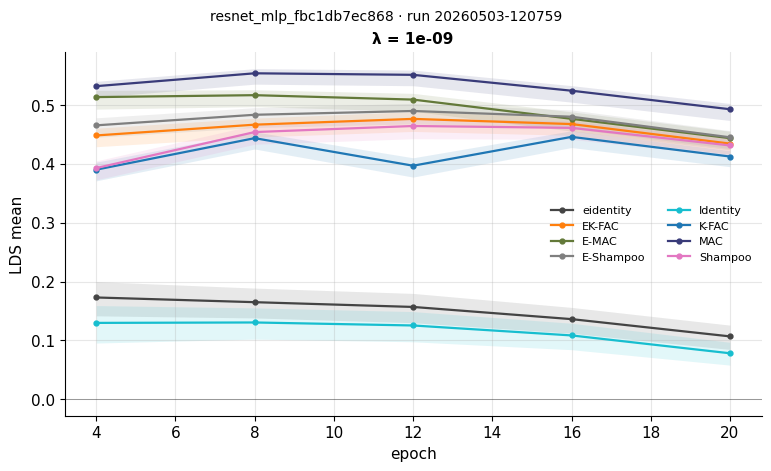

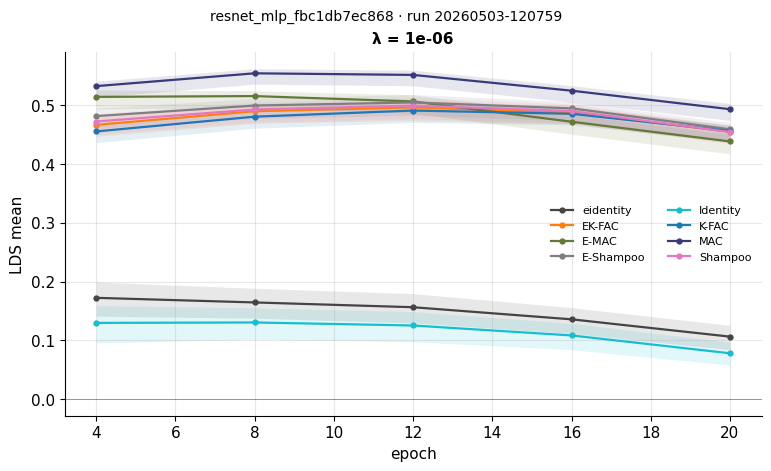

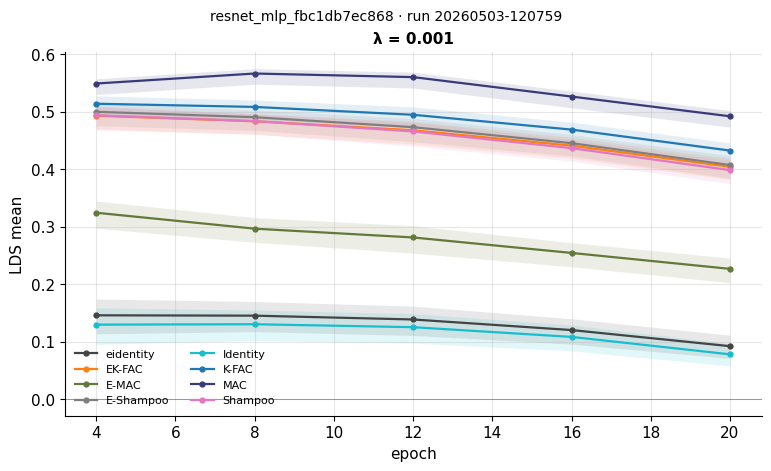

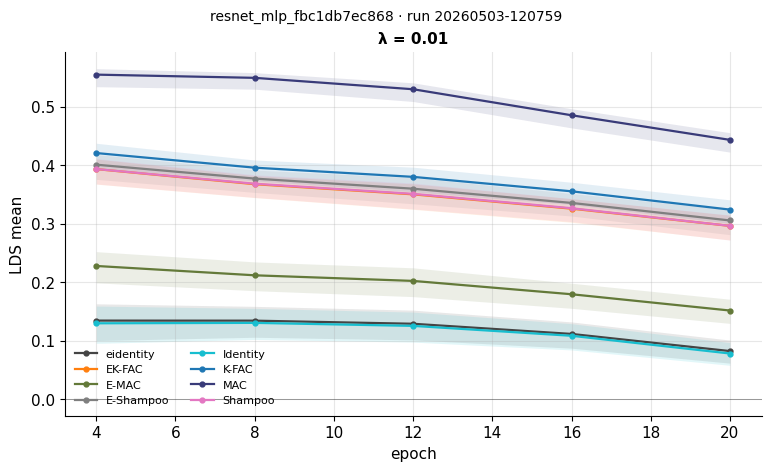

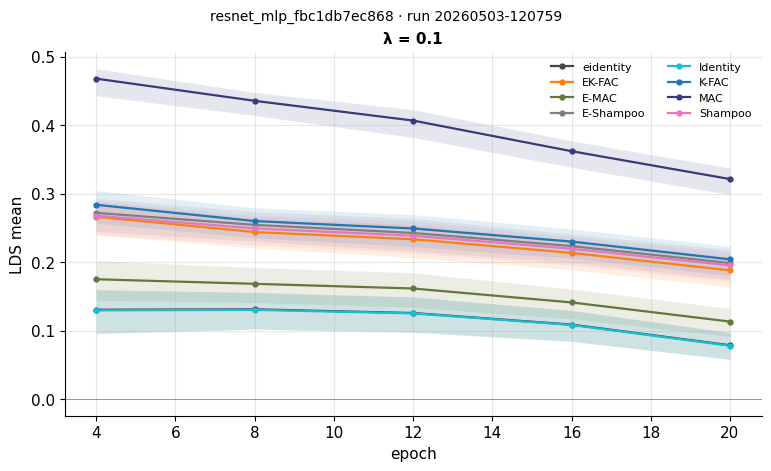

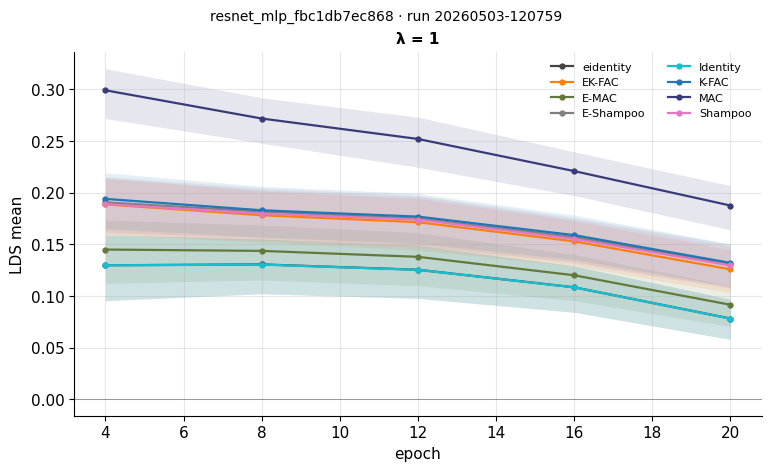

In [21]:
def plot_lds_dampingfix(
    df_sub: pd.DataFrame,
    damping: float,
    *,
    strategy: Optional[str] = None,
    ax=None,
    show_legend: bool = True,
    show_band: bool = True,
    methods: Optional[list[str]] = None,
):
    sub = df_sub[np.isclose(df_sub["damping_value"], damping)]
    if strategy is not None:
        sub = sub[sub["damping_strategy"] == strategy]
    if methods is not None:
        sub = sub[sub["approximator"].isin(methods)]
    methods_here = _order_methods(sub["approximator"].dropna().unique().tolist())

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7.6, 4.6), constrained_layout=True)
    else:
        fig = ax.get_figure()

    style_map = _strategy_styles(sub["damping_strategy"].dropna().unique().tolist())
    _lds_lines_panel(
        ax,
        sub,
        x_col="epoch",
        group_col="approximator",
        color_for=_method_color,
        label_for=lambda m: LABELS.get(m, m),
        log_x=False,
        show_band=show_band,
        style_map=style_map if len(style_map) > 1 else None,
    )
    ax.set_xlabel("epoch")
    ax.set_ylabel("LDS mean")
    ax.set_title(f"λ = {damping:g}", fontsize=11, fontweight="bold")
    if show_legend and methods_here:
        ax.legend(
            loc="best",
            fontsize=8,
            ncol=2 if len(methods_here) > 6 else 1,
            frameon=False,
        )
    return fig


for d in DAMPINGS:
    fig = plot_lds_dampingfix(df_sub, d)
    fig.suptitle(f"{MODEL_ID} · run {RUN_ID}", fontsize=10)
    plt.show()

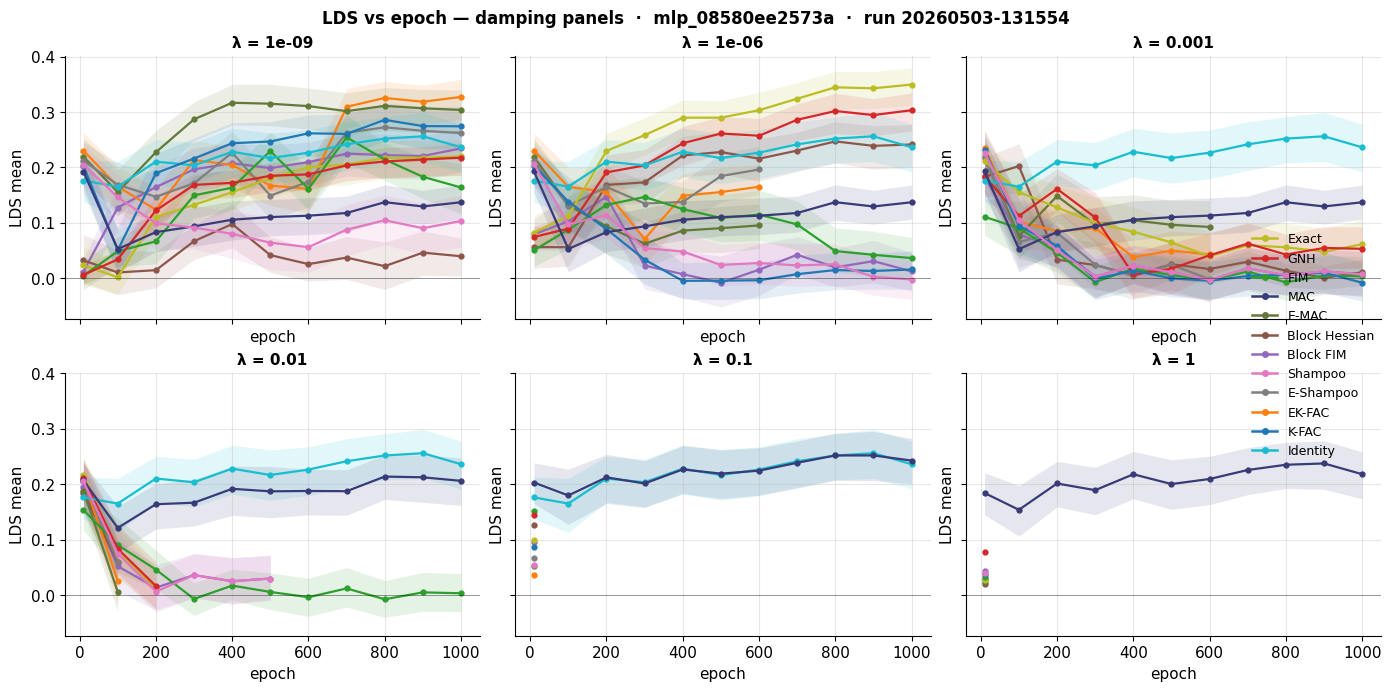

In [11]:
# Variant 2 — one big plot
ncols = min(3, len(DAMPINGS))
nrows = (len(DAMPINGS) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 4.6, nrows * 3.4),
    sharey=True,
    sharex=True,
    constrained_layout=True,
    squeeze=False,
)
for ax, d in zip(axes.flat, DAMPINGS):
    plot_lds_dampingfix(df_sub, d, ax=ax, show_legend=False)
for ax in axes.flat[len(DAMPINGS) :]:
    ax.axis("off")

# one shared method legend
handles = [
    plt.Line2D(
        [0],
        [0],
        color=_method_color(m),
        lw=1.8,
        marker="o",
        ms=4,
        label=LABELS.get(m, m),
    )
    for m in METHODS
]
fig.legend(
    handles=handles,
    loc="center right",
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(1.0, 0.5),
)
fig.suptitle(
    f"LDS vs epoch — damping panels  ·  {MODEL_ID}  ·  run {RUN_ID}",
    fontsize=12,
    fontweight="bold",
)
plt.show()

## Variant 3 — fix **epoch**, vary damping × method

x = damping (log), one line per method.

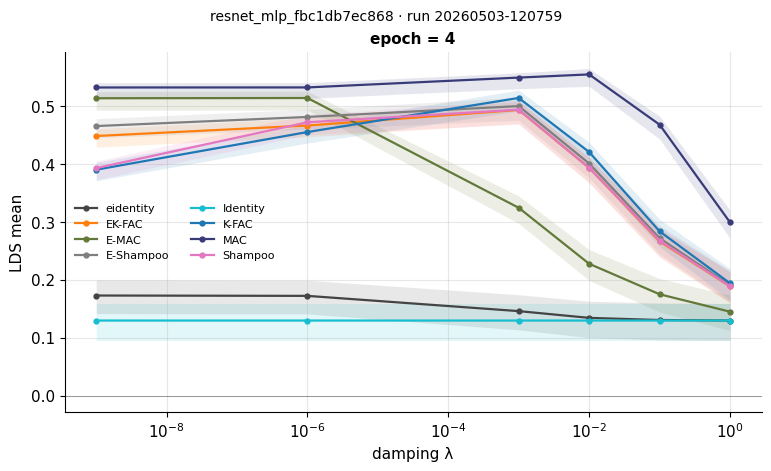

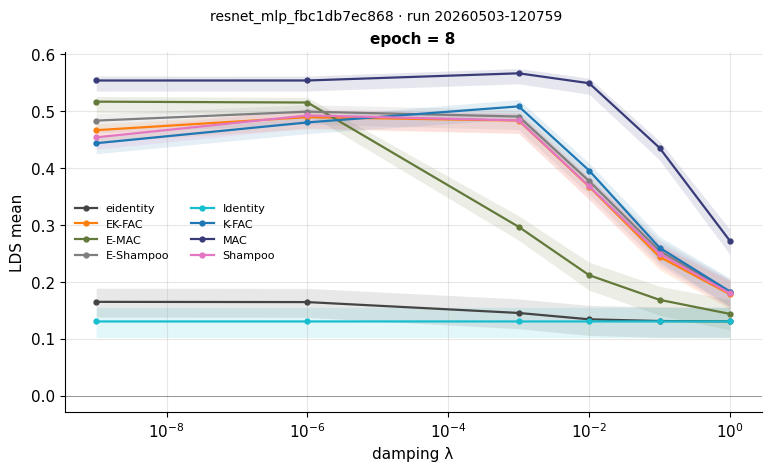

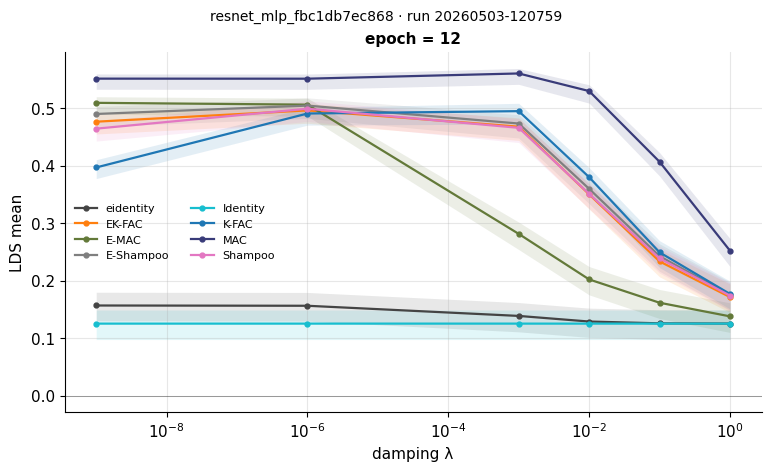

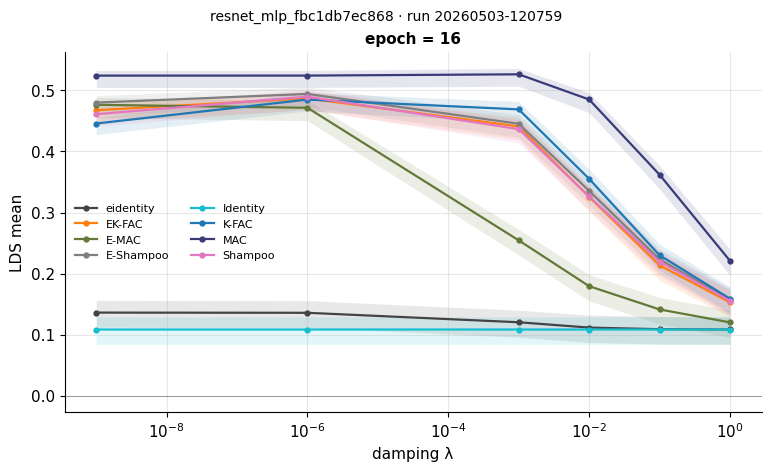

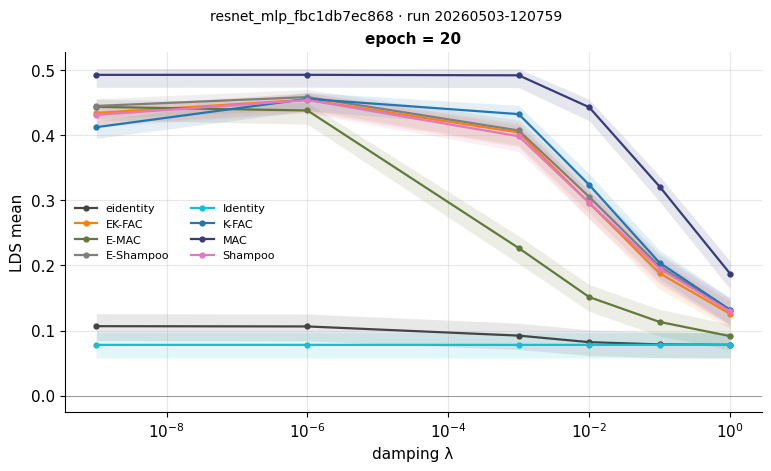

In [22]:
def plot_lds_epochfix(
    df_sub: pd.DataFrame,
    epoch: int,
    *,
    strategy: Optional[str] = None,
    ax=None,
    show_legend: bool = True,
    show_band: bool = True,
    methods: Optional[list[str]] = None,
):
    sub = df_sub[df_sub["epoch"] == epoch]
    if strategy is not None:
        sub = sub[sub["damping_strategy"] == strategy]
    if methods is not None:
        sub = sub[sub["approximator"].isin(methods)]
    methods_here = _order_methods(sub["approximator"].dropna().unique().tolist())

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7.6, 4.6), constrained_layout=True)
    else:
        fig = ax.get_figure()

    style_map = _strategy_styles(sub["damping_strategy"].dropna().unique().tolist())
    _lds_lines_panel(
        ax,
        sub,
        x_col="damping_value",
        group_col="approximator",
        color_for=_method_color,
        label_for=lambda m: LABELS.get(m, m),
        log_x=True,
        show_band=show_band,
        style_map=style_map if len(style_map) > 1 else None,
    )
    ax.set_xlabel("damping λ")
    ax.set_ylabel("LDS mean")
    ax.set_title(f"epoch = {epoch}", fontsize=11, fontweight="bold")
    if show_legend and methods_here:
        ax.legend(
            loc="best",
            fontsize=8,
            ncol=2 if len(methods_here) > 6 else 1,
            frameon=False,
        )
    return fig


for e in EPOCHS:
    fig = plot_lds_epochfix(df_sub, e)
    fig.suptitle(f"{MODEL_ID} · run {RUN_ID}", fontsize=10)
    plt.show()

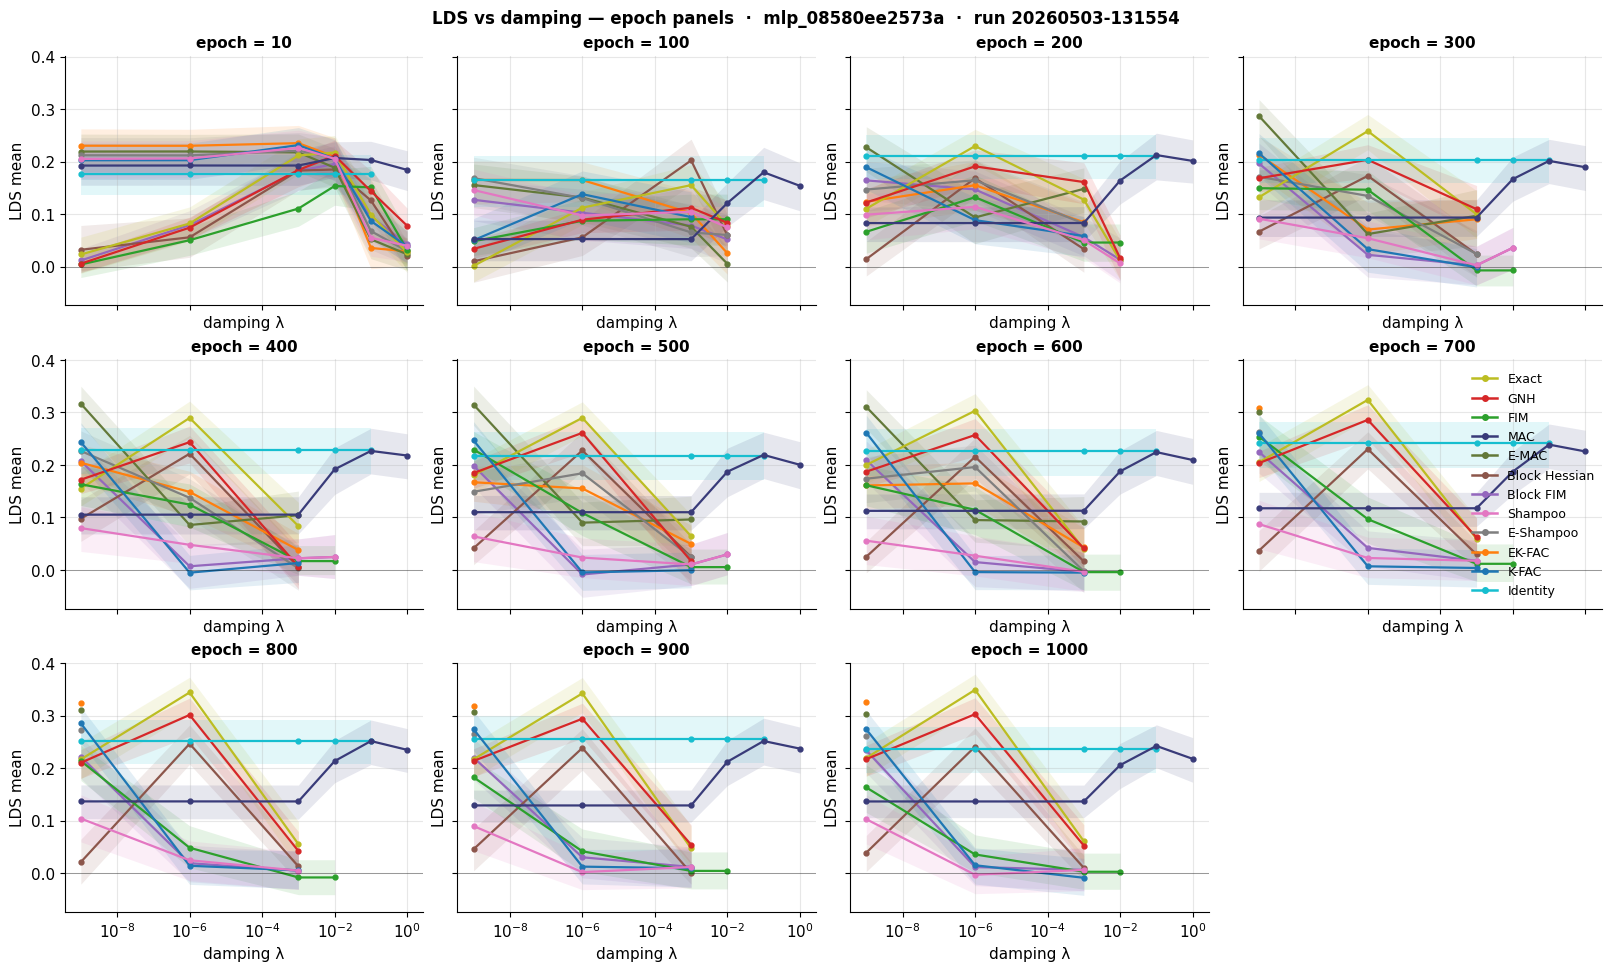

In [13]:
# Variant 3 — one big plot
ncols = min(4, len(EPOCHS))
nrows = (len(EPOCHS) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 4.0, nrows * 3.2),
    sharey=True,
    sharex=True,
    constrained_layout=True,
    squeeze=False,
)
for ax, e in zip(axes.flat, EPOCHS):
    plot_lds_epochfix(df_sub, e, ax=ax, show_legend=False)
for ax in axes.flat[len(EPOCHS) :]:
    ax.axis("off")

handles = [
    plt.Line2D(
        [0],
        [0],
        color=_method_color(m),
        lw=1.8,
        marker="o",
        ms=4,
        label=LABELS.get(m, m),
    )
    for m in METHODS
]
fig.legend(
    handles=handles,
    loc="center right",
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(1.0, 0.5),
)
fig.suptitle(
    f"LDS vs damping — epoch panels  ·  {MODEL_ID}  ·  run {RUN_ID}",
    fontsize=12,
    fontweight="bold",
)
plt.show()

## Variant 4 — heatmap (damping × epoch) per method

Same as `plot_lds_heatmap` from `plot_runs_db.ipynb` cell 30 — reproduced here so this notebook stands alone.

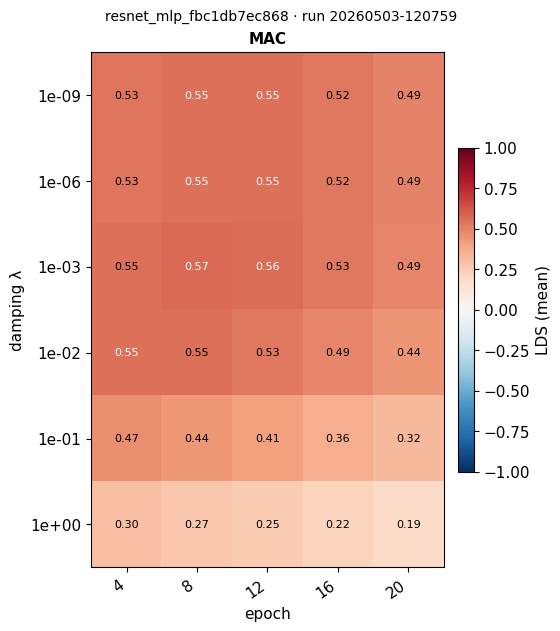

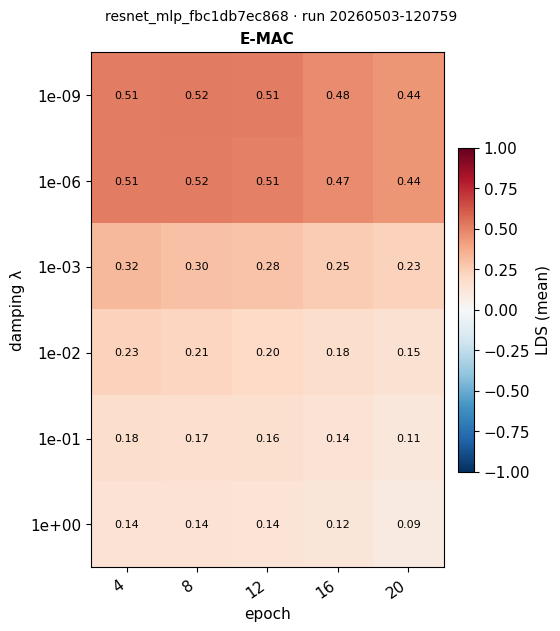

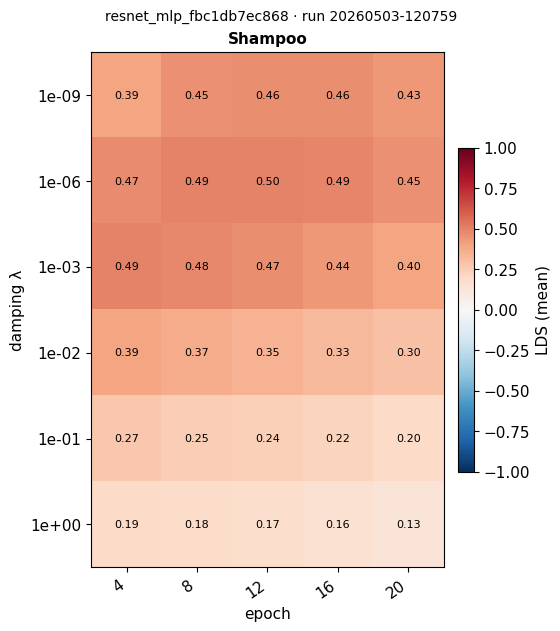

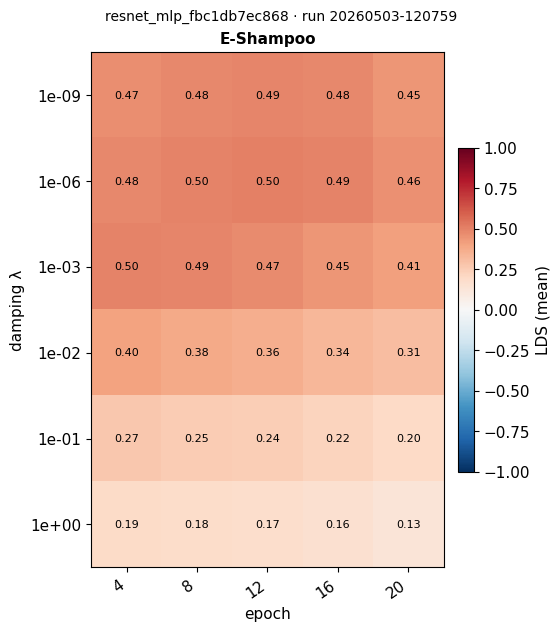

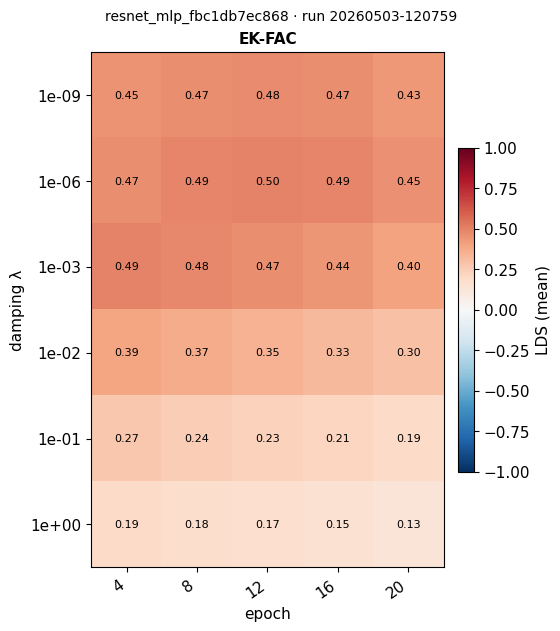

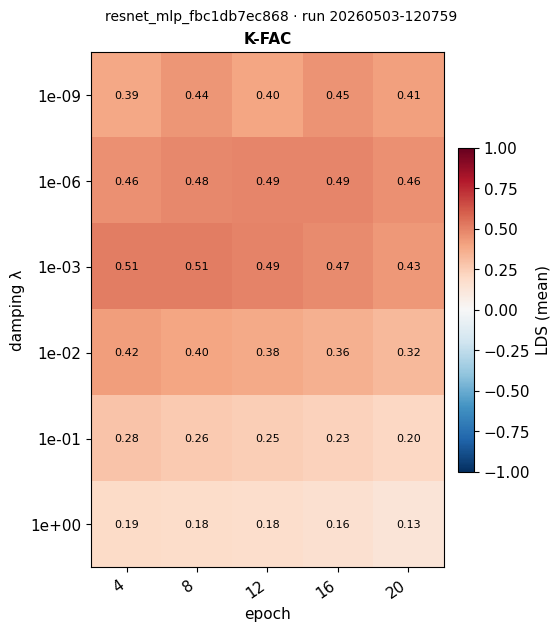

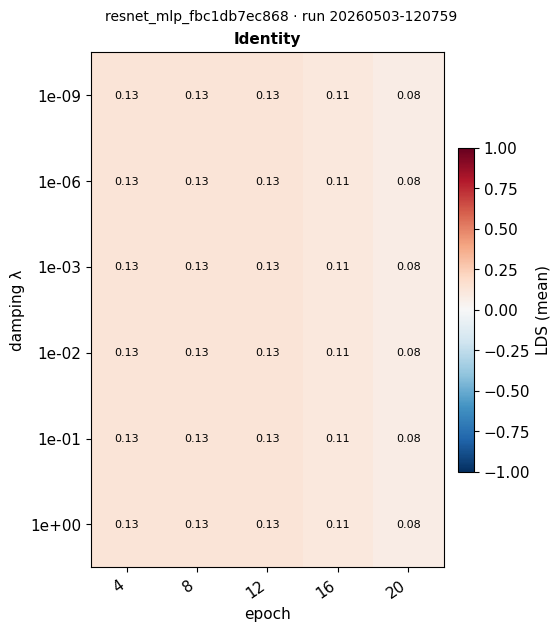

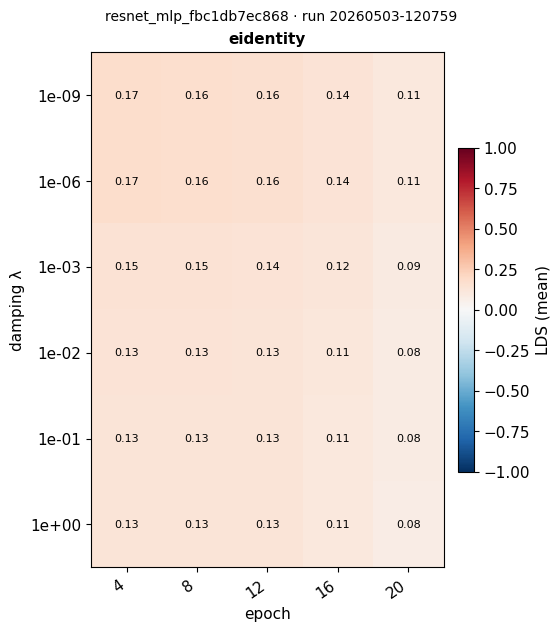

In [23]:
def _lds_pivot(
    df_sub: pd.DataFrame, method: str, strategy: Optional[str] = None
) -> pd.DataFrame:
    sub = df_sub[df_sub["approximator"] == method]
    if strategy is not None:
        sub = sub[sub["damping_strategy"] == strategy]
    if sub.empty:
        return pd.DataFrame()
    return (
        sub.pivot_table(
            index="damping_value",
            columns="epoch",
            values="lds_mean",
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )


def _draw_lds_heatmap(
    ax,
    pivot: pd.DataFrame,
    *,
    vmin: float = -1.0,
    vmax: float = 1.0,
    annotate: bool = True,
):
    if pivot.empty:
        ax.text(
            0.5,
            0.5,
            "no data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
        ax.set_axis_off()
        return None
    arr = pivot.to_numpy()
    im = ax.imshow(arr, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_xticklabels([str(int(x)) for x in pivot.columns], rotation=35, ha="right")
    ax.set_yticklabels([f"{y:.0e}" if y != 0 else "0" for y in pivot.index])
    if annotate:
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                v = arr[i, j]
                if not np.isfinite(v):
                    continue
                color = "white" if abs(v) > 0.55 else "black"
                ax.text(
                    j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=color
                )
    return im


def plot_lds_heatmap_for_method(
    df_sub: pd.DataFrame,
    method: str,
    *,
    ax=None,
    vmin: float = -1.0,
    vmax: float = 1.0,
    annotate: bool = True,
):
    pivot = _lds_pivot(df_sub, method)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(
            figsize=(
                max(5, 0.7 * pivot.shape[1] + 2) if not pivot.empty else 5,
                max(4, 0.7 * pivot.shape[0] + 2) if not pivot.empty else 4,
            ),
            constrained_layout=True,
        )
    else:
        fig = ax.get_figure()
    im = _draw_lds_heatmap(ax, pivot, vmin=vmin, vmax=vmax, annotate=annotate)
    ax.set_xlabel("epoch")
    ax.set_ylabel("damping λ")
    ax.set_title(f"{LABELS.get(method, method)}", fontsize=11, fontweight="bold")
    if own_fig and im is not None:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("LDS (mean)")
    return fig, pivot


for m in METHODS:
    fig, _ = plot_lds_heatmap_for_method(df_sub, m)
    fig.suptitle(f"{MODEL_ID} · run {RUN_ID}", fontsize=10)
    plt.show()

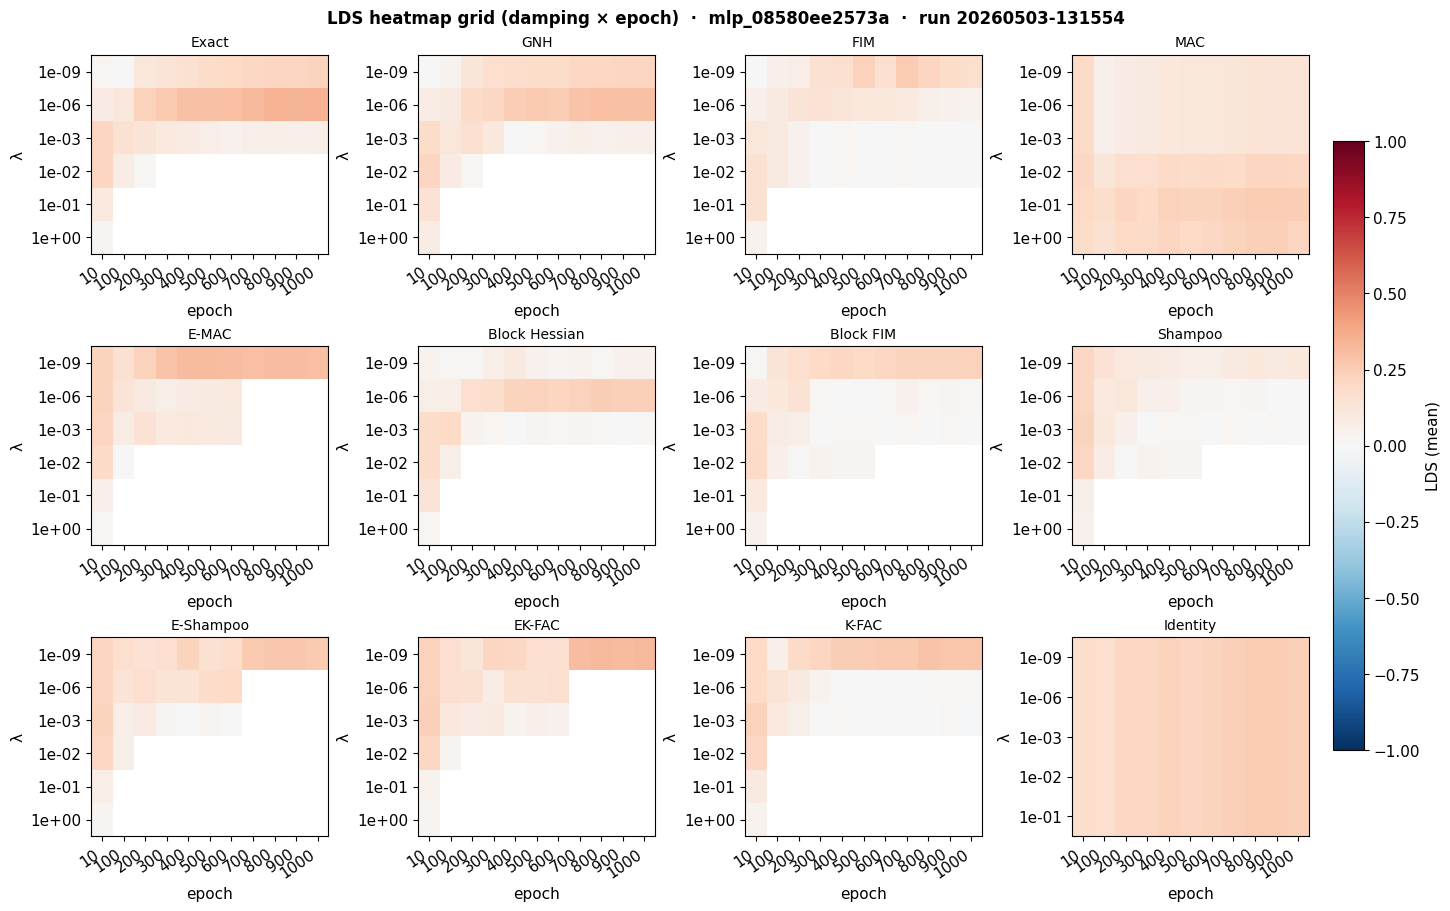

In [15]:
# Variant 4 — one big plot (heatmap grid)
VMIN, VMAX = -1.0, 1.0
ncols = min(4, len(METHODS))
nrows = (len(METHODS) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 3.6, nrows * 3.0),
    constrained_layout=True,
    squeeze=False,
)
last_im = None
for ax, m in zip(axes.flat, METHODS):
    pivot = _lds_pivot(df_sub, m)
    im = _draw_lds_heatmap(ax, pivot, vmin=VMIN, vmax=VMAX, annotate=False)
    if im is not None:
        last_im = im
    ax.set_title(LABELS.get(m, m), fontsize=10)
    ax.set_xlabel("epoch")
    ax.set_ylabel("λ")
for ax in axes.flat[len(METHODS) :]:
    ax.axis("off")
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("LDS (mean)")
fig.suptitle(
    f"LDS heatmap grid (damping × epoch)  ·  {MODEL_ID}  ·  run {RUN_ID}",
    fontsize=12,
    fontweight="bold",
)
plt.show()